# Exercise:
1. Write a code to simulate 2D-ISING model with N grid points per each dimension. 
2. Compute total energy of the system.
3. Compute magnetization of the system.
4. Plot the magnetization as the function of temperature.

In [63]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

# Steps:

1. Create initial configuration with $N^2$ sites
+ cold s= -1
+ random s= +1 or -1
+ hot s = 1

In [64]:
# initial N x N configuration with random spins
def generate_initial_configuration(N):
    return [[random.choice([-1, 1]) for _ in range(N)] for _ in range(N)]

2. Compute changing energy $\Delta E = E_{final} - E_{initial}$ at lattice point $i,j$

In [65]:
def compute_changing_energy(lattice, i, j):
    N = len(lattice)        # size of the lattice
    spin = lattice[i][j]    # value of chosen spin
    n_sum = 0               # sum of 4 neighbors

    # compute the sum of 4 neighbours: (up, down, left, right)
    for id, jd in [((i-1) % N, j), ((i+1) % N, j), (i, (j-1) % N), (i, (j+1) % N)]:
        n_sum += lattice[id][jd]

    # compute the initial and final energy
    E_i = -spin * n_sum
    E_f = spin * n_sum

    dE = E_f - E_i

    return dE


# l = [[-1, 1, -1], [1, -1, 1], [-1, 1, -1]]
# print(compute_changing_energy(l, 1, 1))

3. Generate new configuration using Monte Carlo Metropolis method
+ if $\Delta E <= 0$, accept new spin or flip spin
+ if $\Delta E > 0$, flip spin based on Boltzmann distribution:

	- $p <= e^{-\beta \Delta E}$: accept new spin

	- $p > e^{-\beta \Delta E}$: reject new spin

In [66]:
def generate_new_configuration(lattice, i, j, beta):
    # compute the change in energy if we flip the spin at (i, j)
    dE = compute_changing_energy(lattice, i, j)

    # decide whether to flip the spin based on the Metropolis criterion
    if dE <= 0:
        lattice[i][j] *= -1
    else:
        p = random.random()
        # flip the spin with probability exp(-beta * dE)
        if p < math.exp(-beta * dE):
            lattice[i][j] *= -1

4. Compute 2 quatities:

	a. total energy of the system
		$$E = -\sum_{i,j} s_i s_j$$ 
	where $i,j$ are neighbourhoods.
	
	b. Compute magnetization for each configuration after burn-in period

	$$ \langle |M| \rangle = \dfrac{1}{n}\sum_{i =1}^{n} |M_i|$$
	 with $n$ is the number of configurations and
	$$M_i = \dfrac{1}{N^2}\sum_{j=1}^{N^2} s_j$$
	c. Plot the magnetization and energy  as the function of $\beta$. 

In [67]:
def compute_total_energy(lattice):
    N = len(lattice)    # size of the lattice
    E_total = 0         # total energy of the configuration

    for i in range(N):
        for j in range(N):
            spin = lattice[i][j]

            # get the energy of two neighbors: (right, down)
            s_right = lattice[i][(j+1) % N]
            s_down = lattice[(i+1) % N][j]

            E_total += -spin * (s_right + s_down)

    return E_total

In [68]:
# def compute_magnetization(lattice):
#     M_total = 0

#     for i in range(N):
#         for j in range(N):
#             M_total += lattice[i][j]

#     return M_total / N**2

def compute_magnetization(lattice):
    return np.mean(lattice)

In [69]:
def simulate(N, beta, burn_in_steps=1000, measure_steps=2000):
    lattice = generate_initial_configuration(N)

    # burn-in phase
    for _ in range(burn_in_steps):
        for _ in range(N**2):
            i = random.randint(0, N-1)
            j = random.randint(0, N-1)
            generate_new_configuration(lattice, i, j, beta)

    # init lists to store energy and magnetization values
    E = []
    M = []

    # measurement phase
    for _ in range(measure_steps):
        for _ in range(N**2):
            i = random.randint(0, N-1)
            j = random.randint(0, N-1)
            generate_new_configuration(lattice, i, j, beta)

        # compute and store energy and magnetization after each measurement step
        e = compute_total_energy(lattice)
        m = compute_magnetization(lattice)

        E.append(e)
        M.append(abs(m))

    # compute mean energy and magnetization
    mean_E = sum(E) / len(E)
    mean_M = sum(M) / len(M)

    return E, M, mean_E, mean_M

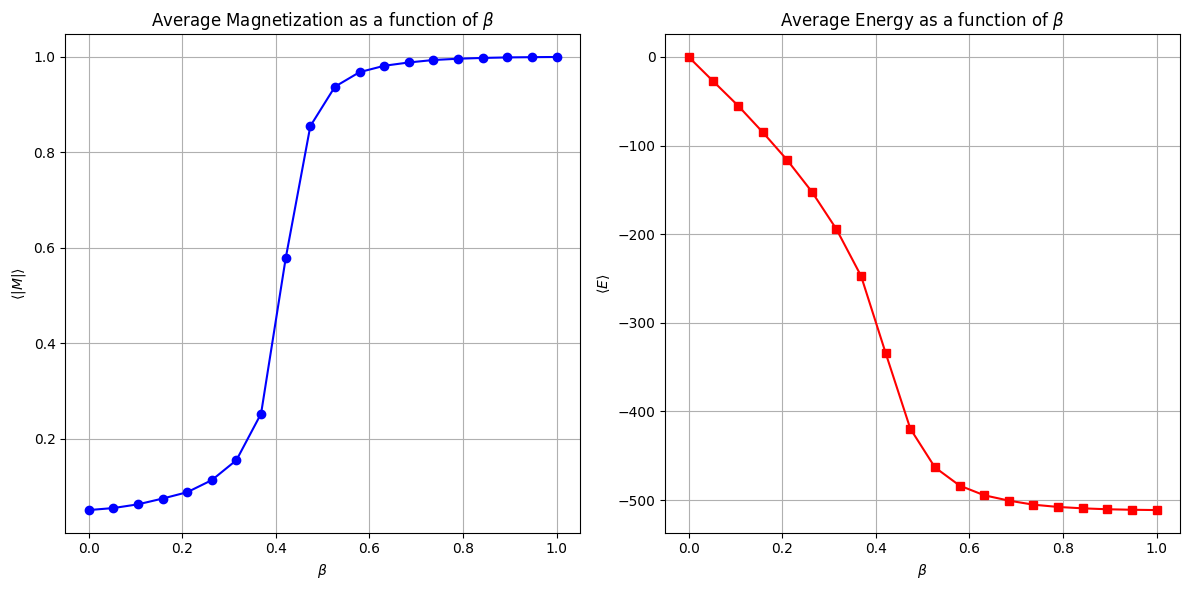

In [70]:
betas = np.linspace(0.0, 1.0, 20)

mean_Es = []
mean_Ms = []

for beta in betas:
    E, M, mean_E, mean_M = simulate(16, beta)
    mean_Es.append(mean_E)
    mean_Ms.append(mean_M)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# magnetization plot
ax1.plot(betas, mean_Ms, 'o-', color='blue')
ax1.set_title("Average Magnetization as a function of $\\beta$")
ax1.set_xlabel("$\\beta$")
ax1.set_ylabel("$\\langle |M| \\rangle$")
ax1.grid()

# energy plot
ax2.plot(betas, mean_Es, 's-', color='red')
ax2.set_title("Average Energy as a function of $\\beta$")
ax2.set_xlabel("$\\beta$")
ax2.set_ylabel("$\\langle E \\rangle$")
ax2.grid()

plt.tight_layout()
plt.show()